In [19]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import os
import shutil
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import cv2
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
from tqdm import tqdm
from datetime import datetime

print("All imports successful!")

All imports successful!


In [29]:
# ── config ────────────────────────────────────────────────
FRAMES_FOLDER  = "/Users/iris/Desktop/ETH/DAS Project/camera-trap-gan/data/frames/FH102_02"
CSV_PATH       = "/Users/iris/Desktop/ETH/DAS Project/camera-trap-gan/data/Weinstein2018MEE_ground_truth.csv"
OUTPUT_FOLDER  = "/Users/iris/Desktop/ETH/DAS Project/camera-trap-gan/outputs/FH102_02"
VIDEO_NAME     = "FH102_02"
timestamp = datetime.now().strftime("%Y%m%d_%H")
IMG_SIZE       = 256
BATCH_SIZE     = 32 ## 16
EPOCHS         = 10
LEARNING_RATE  = 0.001
LATENT_DIM     = 512
THRESHOLD_STD  = 2

os.makedirs(OUTPUT_FOLDER, exist_ok=True)

device = torch.device("mps"  if torch.backends.mps.is_available() else
                      "cuda" if torch.cuda.is_available() else "cpu")
# save config to text file so you know what settings this run used
config_summary = f"""
Run timestamp  : {timestamp}
Video          : {VIDEO_NAME}
Frames folder  : {FRAMES_FOLDER}
Image size     : {IMG_SIZE}
Batch size     : {BATCH_SIZE}
Epochs         : {EPOCHS}
Learning rate  : {LEARNING_RATE}
Latent dim     : {LATENT_DIM}
Threshold std  : {THRESHOLD_STD}
Device         : {device}
"""

with open(os.path.join(OUTPUT_FOLDER, "config.txt"), "w") as f:
    f.write(config_summary)

print(config_summary)



Run timestamp  : 20260314_20
Video          : FH102_02
Frames folder  : /Users/iris/Desktop/ETH/DAS Project/camera-trap-gan/data/frames/FH102_02
Image size     : 256
Batch size     : 32
Epochs         : 10
Learning rate  : 0.001
Latent dim     : 512
Threshold std  : 2
Device         : mps



In [7]:
df = pd.read_csv(CSV_PATH)

# peek at structure
print("CSV columns:", df.columns.tolist())
print(f"Total rows: {len(df)}")
print("\nFirst 10 rows:")
df.head(10)

CSV columns: ['Video', 'Frame', 'Truth']
Total rows: 39621

First 10 rows:


,Video,Frame,Truth
0,FH102_02,2,Negative
1,FH102_02,3,Negative
2,FH102_02,4,Negative
3,FH102_02,5,Negative
4,FH102_02,6,Negative
5,FH102_02,7,Negative
6,FH102_02,9,Negative
7,FH102_02,17,Negative
8,FH102_02,35,Negative
9,FH102_02,38,Negative


In [8]:
df_video = df[df['Video'] == VIDEO_NAME].copy()

print(f"Video: {VIDEO_NAME}")
print(f"Total frames in CSV : {len(df_video)}")
print(f"Positive (bird)     : {(df_video['Truth'] == 'Positive').sum()}")
print(f"Negative (normal)   : {(df_video['Truth'] == 'Negative').sum()}")

# build set of positive frame filenames
# CSV is 1-indexed → subtract 1 to match frame_00000.jpg
positive_frames = set(
    f"frame_{(row['Frame'] - 1):05d}.jpg"
    for _, row in df_video.iterrows()
    if row['Truth'] == 'Positive'
)

print(f"\nBird frames to find: {len(positive_frames)}")
print(f"Example filenames: {list(positive_frames)[:5]}")

Video: FH102_02
Total frames in CSV : 969
Positive (bird)     : 39
Negative (normal)   : 930

Bird frames to find: 33
Example filenames: ['frame_01016.jpg', 'frame_10924.jpg', 'frame_10964.jpg', 'frame_00985.jpg', 'frame_18636.jpg']


In [10]:
# ── 1. dataset ──────────────────────────────────────────────
class CameraTrapDataset(Dataset):
    def __init__(self, frames_folder, img_size=256):
        self.frame_paths = sorted([
            os.path.join(frames_folder, f)
            for f in os.listdir(frames_folder)
            if f.endswith('.jpg')
        ])
        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5],
                                 [0.5, 0.5, 0.5])
        ])

    def __len__(self):
        return len(self.frame_paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.frame_paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        return self.transform(img), self.frame_paths[idx]

# create dataset
dataset = CameraTrapDataset(FRAMES_FOLDER, img_size=IMG_SIZE)
print(f"Total frames loaded: {len(dataset)}")

# quick sanity check — load one frame
sample_frame, sample_path = dataset[0]
print(f"Sample frame shape : {sample_frame.shape}")
print(f"Sample frame range : {sample_frame.min():.2f} to {sample_frame.max():.2f}")
print(f"Sample path        : {os.path.basename(sample_path)}")

Total frames loaded: 21593
Sample frame shape : torch.Size([3, 256, 256])
Sample frame range : -1.00 to 1.00
Sample path        : frame_00000.jpg


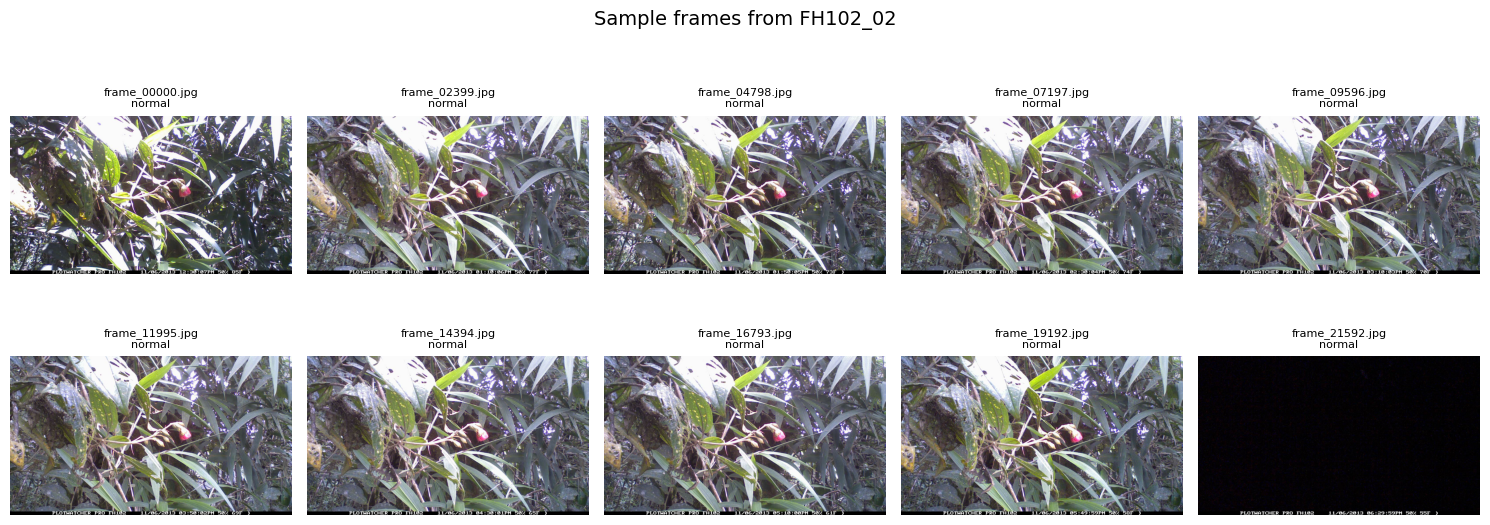

In [16]:
# ── 1.1 Sample Frame ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Sample frames from FH102_02", fontsize=14)

# pick 10 evenly spaced frames
indices = np.linspace(0, len(dataset)-1, 10, dtype=int)

for ax, idx in zip(axes.flatten(), indices):
    img = cv2.imread(dataset.frame_paths[idx])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    filename = os.path.basename(dataset.frame_paths[idx])
    is_bird = "BIRD" if filename in positive_frames else "normal"
    ax.imshow(img)
    ax.set_title(f"{filename}\n{is_bird}", fontsize=8,
                 color='green' if is_bird == "BIRD" else 'black')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [17]:
# ── 2. model ──────────────────────────────────────────────
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=512):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64,  kernel_size=4, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1), nn.BatchNorm2d(512), nn.ReLU(),
            nn.Flatten(),
            nn.Linear(512 * 16 * 16, latent_dim)
        )
        self.decoder_fc = nn.Linear(latent_dim, 512 * 16 * 16)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64,  kernel_size=4, stride=2, padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.ConvTranspose2d(64,  3,   kernel_size=4, stride=2, padding=1), nn.Tanh()
        )

    def forward(self, x):
        z = self.encoder(x)
        x = self.decoder_fc(z)
        x = x.view(-1, 512, 16, 16)
        return self.decoder(x)

    def anomaly_score(self, x):
        return torch.mean((x - self.forward(x)) ** 2, dim=[1, 2, 3])

model = Autoencoder(latent_dim=LATENT_DIM).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Model ready — {total_params:,} parameters")

Model ready — 139,864,579 parameters


In [30]:
# ── 3. train ──────────────────────────────────────────────
train_loader = DataLoader(dataset, batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=0)
optimizer    = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion    = nn.MSELoss()
losses       = []

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0

    for frames, _ in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}",
                          leave=False):
        frames = frames.to(device)
        optimizer.zero_grad()
        loss = criterion(model(frames), frames)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    epoch_loss /= len(train_loader)
    losses.append(epoch_loss)
    print(f"Epoch [{epoch+1}/{EPOCHS}]  Loss: {epoch_loss:.4f}")

    if (epoch + 1) % 5 == 0:
        torch.save(model.state_dict(),
                   os.path.join(OUTPUT_FOLDER, f"model_epoch{epoch+1}.pth"))
        print(f"  → checkpoint saved")

torch.save(model.state_dict(), os.path.join(OUTPUT_FOLDER, "model.pth"))
print("\nTraining complete!")


KeyboardInterrupt: 

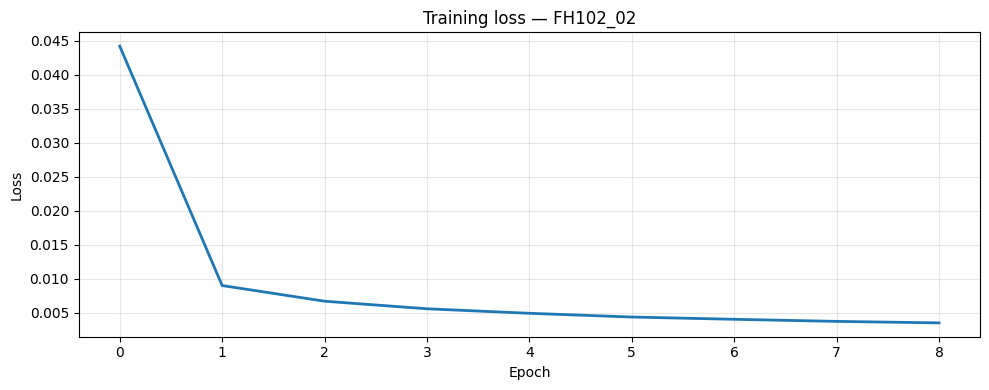

Final loss: 0.0035


In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(losses, linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss — FH102_02")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, "loss_curve.png"))
plt.show()
print(f"Final loss: {losses[-1]:.4f}")

In [ ]:
# ── 4. detect ──────────────────────────────────────────────
detect_loader = DataLoader(dataset, batch_size=BATCH_SIZE,
                           shuffle=False, num_workers=0)
all_scores = []
all_paths  = []

model.eval()
with torch.no_grad():
    for frames, paths in tqdm(detect_loader, desc="Scoring frames"):
        frames = frames.to(device)
        scores = model.anomaly_score(frames)
        all_scores.extend(scores.cpu().numpy())
        all_paths.extend(paths)

scores_np = np.array(all_scores)
threshold = scores_np.mean() + THRESHOLD_STD * scores_np.std()

print(f"Scored {len(scores_np)} frames")
print(f"Mean      : {scores_np.mean():.4f}")
print(f"Std       : {scores_np.std():.4f}")
print(f"Threshold : {threshold:.4f}")
print(f"Flagged   : {(scores_np > threshold).sum()} frames")

Scoring frames:  85%|████████▌ | 575/675 [04:46<00:45,  2.18it/s]

In [ ]:
# ── 4. evaluate ──────────────────────────────────────────────
y_true = np.array([1 if os.path.basename(p) in positive_frames else 0
                   for p in all_paths])
y_pred = np.array([1 if s > threshold else 0
                   for s in all_scores])

precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='binary', zero_division=0)
cm = confusion_matrix(y_true, y_pred)

print(f"{'='*50}")
print(f"  RESULTS — {VIDEO_NAME}")
print(f"{'='*50}")
print(f"  Total frames    : {len(y_true)}")
print(f"  Bird frames     : {y_true.sum()}")
print(f"  Flagged frames  : {y_pred.sum()}")
print(f"  Precision       : {precision:.3f}")
print(f"  Recall          : {recall:.3f}")
print(f"  F1 score        : {f1:.3f}")
print(f"\nConfusion matrix:")
print(f"                  Predicted")
print(f"                  Normal   Bird")
print(f"  Actual Normal   {cm[0][0]:6d}   {cm[0][1]:4d}")
print(f"  Actual Bird     {cm[1][0]:6d}   {cm[1][1]:4d}")

In [ ]:
# ── 5. plot results ──────────────────────────────────────────────
bird_indices = [i for i, p in enumerate(all_paths)
                if os.path.basename(p) in positive_frames]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8))

# scores over time
ax1.plot(scores_np, linewidth=0.5, color='steelblue', alpha=0.8, label='anomaly score')
ax1.axhline(y=threshold, color='red', linestyle='--', linewidth=1,
            label=f'threshold ({threshold:.4f})')
for idx in bird_indices:
    ax1.axvline(x=idx, color='green', alpha=0.2, linewidth=0.5)
ax1.plot([], [], color='green', alpha=0.5, linewidth=2, label='ground truth bird')
ax1.set_xlabel("Frame number (time →)")
ax1.set_ylabel("Anomaly score")
ax1.set_title(f"{VIDEO_NAME} — Precision: {precision:.2f}  Recall: {recall:.2f}  F1: {f1:.2f}")
ax1.legend()

# histogram
ax2.hist(scores_np[y_true == 0], bins=50, alpha=0.6,
         color='steelblue', label='normal frames')
ax2.hist(scores_np[y_true == 1], bins=50, alpha=0.6,
         color='green', label='bird frames')
ax2.axvline(x=threshold, color='red', linestyle='--',
            linewidth=1, label=f'threshold')
ax2.set_xlabel("Anomaly score")
ax2.set_ylabel("Number of frames")
ax2.set_title("Score distribution")
ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, "results.png"))
plt.show()

In [ ]:
# ── 6. save detected results ──────────────────────────────────────────────
ranked = sorted(zip(all_scores, all_paths), reverse=True)
suspicious_folder = os.path.join(OUTPUT_FOLDER, "suspicious_frames")
os.makedirs(suspicious_folder, exist_ok=True)

for f in os.listdir(suspicious_folder):
    os.remove(os.path.join(suspicious_folder, f))

for i, (score, path) in enumerate(ranked[:20]):
    filename = os.path.basename(path)
    is_bird  = "BIRD" if filename in positive_frames else "normal"
    dest = os.path.join(suspicious_folder,
           f"rank{i+1:02d}_{is_bird}_score{score:.4f}_{filename}")
    shutil.copy(path, dest)

print(f"Top 20 saved to {suspicious_folder}")
print("Filenames labelled BIRD or normal")

# show top 5 suspicious frames inline
fig, axes = plt.subplots(1, 5, figsize=(15, 4))
fig.suptitle("Top 5 most anomalous frames", fontsize=12)

for ax, (score, path) in zip(axes, ranked[:5]):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    filename = os.path.basename(path)
    is_bird  = "BIRD" if filename in positive_frames else "normal"
    ax.imshow(img)
    ax.set_title(f"{is_bird}\nscore: {score:.4f}", fontsize=9,
                 color='green' if is_bird == 'BIRD' else 'red')
    ax.axis('off')

plt.tight_layout()
plt.show()